# Exploratory Data Analysis - Olist Sales Intelligence Dataset

This notebook explores the raw ecommerce datasets in `data/raw` and prepares the analytical context for the sales intelligence platform.

## Executive Summary

- The raw layer contains **9 CSV files** covering orders, customers, sellers, products, payments, reviews, and geolocation.
- The dataset has **99,441 unique orders**, **96,096 unique customers**, **3,095 sellers**, and **32,951 products**.
- Order purchases span **2016-09-04 to 2018-10-17**.
- Total payment value is **R$ 16,008,872.12**, while merchandise value is **R$ 13,591,643.70** and freight value is **R$ 2,251,909.54**.
- Average payment per paid order is **R$ 160.99**.
- Average review score is **4.09 / 5**.
- Delivered orders have a median delivery time of **10 days** and a late delivery rate of **8.1%**.
- The leading customer state by order count is **SP** with **41,746 orders**.
- The leading product category by item revenue is **health_beauty** with **R$ 1,258,681.34** in merchandise revenue.
- The largest payment type by value is **credit_card**.

## Dataset Profile

| dataset | rows | columns | duplicate_rows | missing_cells | missing_pct |
| --- | --- | --- | --- | --- | --- |
| customers | 99441 | 5 | 0 | 0 | 0.00 |
| geolocation | 1000163 | 5 | 261831 | 0 | 0.00 |
| orders | 99441 | 8 | 0 | 4908 | 0.62 |
| order_items | 112650 | 7 | 0 | 0 | 0.00 |
| payments | 103886 | 5 | 0 | 0 | 0.00 |
| reviews | 99224 | 7 | 0 | 145903 | 21.01 |
| products | 32951 | 9 | 0 | 2448 | 0.83 |
| sellers | 3095 | 4 | 0 | 0 | 0.00 |
| category_translation | 71 | 2 | 0 | 0 | 0.00 |

## Highest Missingness Areas

| dataset | rows | columns | duplicate_rows | missing_cells | missing_pct |
| --- | --- | --- | --- | --- | --- |
| reviews | 99224 | 7 | 0 | 145903 | 21.01 |
| orders | 99441 | 8 | 0 | 4908 | 0.62 |
| products | 32951 | 9 | 0 | 2448 | 0.83 |
| customers | 99441 | 5 | 0 | 0 | 0.00 |


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

RAW_DIR = Path('data/raw')


In [2]:
files = {
    'customers': 'olist_customers_dataset.csv',
    'geolocation': 'olist_geolocation_dataset.csv',
    'orders': 'olist_orders_dataset.csv',
    'order_items': 'olist_order_items_dataset.csv',
    'payments': 'olist_order_payments_dataset.csv',
    'reviews': 'olist_order_reviews_dataset.csv',
    'products': 'olist_products_dataset.csv',
    'sellers': 'olist_sellers_dataset.csv',
    'category_translation': 'product_category_name_translation.csv',
}

dfs = {name: pd.read_csv(RAW_DIR / filename) for name, filename in files.items()}
{name: df.shape for name, df in dfs.items()}


{'customers': (99441, 5),
 'geolocation': (1000163, 5),
 'orders': (99441, 8),
 'order_items': (112650, 7),
 'payments': (103886, 5),
 'reviews': (99224, 7),
 'products': (32951, 9),
 'sellers': (3095, 4),
 'category_translation': (71, 2)}

## 1. Raw Data Quality

This section checks row counts, column counts, duplicate rows, missing values, and column types for each raw dataset.

In [3]:
profile = []
for name, df in dfs.items():
    profile.append({
        'dataset': name,
        'rows': len(df),
        'columns': df.shape[1],
        'duplicate_rows': df.duplicated().sum(),
        'missing_cells': df.isna().sum().sum(),
        'missing_pct': df.isna().sum().sum() / df.size,
    })

profile_df = pd.DataFrame(profile).sort_values('rows', ascending=False)
profile_df


,dataset,rows,columns,duplicate_rows,missing_cells,missing_pct
1,geolocation,1000163,5,261831,0,0.00
3,order_items,112650,7,0,0,0.00
4,payments,103886,5,0,0,0.00
0,customers,99441,5,0,0,0.00
2,orders,99441,8,0,4908,0.01
5,reviews,99224,7,0,145903,0.21
6,products,32951,9,0,2448,0.01
7,sellers,3095,4,0,0,0.00
8,category_translation,71,2,0,0,0.00


In [4]:
missing_summary = []
for name, df in dfs.items():
    missing = df.isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0]
    for column, missing_count in missing.items():
        missing_summary.append({
            'dataset': name,
            'column': column,
            'missing_count': missing_count,
            'missing_pct': missing_count / len(df),
        })

missing_df = pd.DataFrame(missing_summary).sort_values('missing_count', ascending=False)
missing_df


,dataset,column,missing_count,missing_pct
3,reviews,review_comment_title,87656,0.88
4,reviews,review_comment_message,58247,0.59
0,orders,order_delivered_customer_date,2965,0.03
1,orders,order_delivered_carrier_date,1783,0.02
5,products,product_category_name,610,0.02
7,products,product_name_lenght,610,0.02
6,products,product_description_lenght,610,0.02
8,products,product_photos_qty,610,0.02
2,orders,order_approved_at,160,0.00
9,products,product_weight_g,2,0.00


In [5]:
for name, df in dfs.items():
    print(f'\n{name}:')
    display(df.head())
    display(pd.DataFrame({'dtype': df.dtypes.astype(str), 'missing': df.isna().sum()}))



customers:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,dtype,missing
customer_id,str,0
customer_unique_id,str,0
customer_zip_code_prefix,int64,0
customer_city,str,0
customer_state,str,0



geolocation:


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.55,-46.64,sao paulo,SP
1,1046,-23.55,-46.64,sao paulo,SP
2,1046,-23.55,-46.64,sao paulo,SP
3,1041,-23.54,-46.64,sao paulo,SP
4,1035,-23.54,-46.64,sao paulo,SP


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


,dtype,missing
seller_id,str,0
seller_zip_code_prefix,int64,0
seller_city,str,0
seller_state,str,0



category_translation:


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


,dtype,missing
product_category_name,str,0
product_category_name_english,str,0


## 2. Prepare Analytical Tables

The raw files are joined into order-level and item-level analytical tables for sales, delivery, category, payment, and review analysis.

In [6]:
customers = dfs['customers'].copy()
geolocation = dfs['geolocation'].copy()
orders = dfs['orders'].copy()
items = dfs['order_items'].copy()
payments = dfs['payments'].copy()
reviews = dfs['reviews'].copy()
products = dfs['products'].copy()
sellers = dfs['sellers'].copy()
translations = dfs['category_translation'].copy()

for col in [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
]:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')


In [7]:
order_payments = payments.groupby('order_id', as_index=False)['payment_value'].sum()
order_items = items.groupby('order_id', as_index=False).agg(
    item_count=('order_item_id', 'count'),
    merchandise_value=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    seller_count=('seller_id', 'nunique'),
)

orders_enriched = (
    orders
    .merge(customers, on='customer_id', how='left')
    .merge(order_payments, on='order_id', how='left')
    .merge(order_items, on='order_id', how='left')
)

orders_enriched['delivery_days'] = (
    orders_enriched['order_delivered_customer_date'] - orders_enriched['order_purchase_timestamp']
).dt.days
orders_enriched['estimated_delivery_days'] = (
    orders_enriched['order_estimated_delivery_date'] - orders_enriched['order_purchase_timestamp']
).dt.days
orders_enriched['late_delivery'] = orders_enriched['order_delivered_customer_date'] > orders_enriched['order_estimated_delivery_date']

orders_enriched.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_value,item_count,merchandise_value,freight_value,seller_count,delivery_days,estimated_delivery_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.00,29.99,8.72,1.00,8.00,15,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.00,118.70,22.76,1.00,13.00,19,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,1.00,159.90,19.22,1.00,9.00,26,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,72.20,1.00,45.00,27.20,1.00,13.00,26,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,28.62,1.00,19.90,8.72,1.00,2.00,12,False


In [8]:
items_products = (
    items
    .merge(products, on='product_id', how='left')
    .merge(translations, on='product_category_name', how='left')
    .merge(sellers, on='seller_id', how='left')
)
items_products['category'] = items_products['product_category_name_english'].fillna(
    items_products['product_category_name']
).fillna('unknown')
items_products.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.00,598.00,4.00,650.00,28.00,9.00,14.00,cool_stuff,27277,volta redonda,SP,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.00,239.00,2.00,"30,000.00",50.00,30.00,40.00,pet_shop,3471,sao paulo,SP,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.00,695.00,2.00,"3,050.00",33.00,13.00,33.00,furniture_decor,37564,borda da mata,MG,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.00,480.00,1.00,200.00,16.00,10.00,15.00,perfumery,14403,franca,SP,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.00,409.00,1.00,"3,750.00",35.00,40.00,30.00,garden_tools,87900,loanda,PR,garden_tools


## 3. Order and Revenue Trends

In [9]:
kpis = pd.Series({
    'unique_orders': orders['order_id'].nunique(),
    'unique_customers': customers['customer_unique_id'].nunique(),
    'unique_sellers': sellers['seller_id'].nunique(),
    'unique_products': products['product_id'].nunique(),
    'payment_value': payments['payment_value'].sum(),
    'merchandise_value': items['price'].sum(),
    'freight_value': items['freight_value'].sum(),
    'avg_payment_per_order': order_payments['payment_value'].mean(),
    'avg_review_score': reviews['review_score'].mean(),
    'median_delivery_days': orders_enriched['delivery_days'].median(),
    'late_delivery_rate': orders_enriched.loc[orders_enriched['order_delivered_customer_date'].notna(), 'late_delivery'].mean(),
})
kpis


unique_orders               99,441.00
unique_customers            96,096.00
unique_sellers               3,095.00
unique_products             32,951.00
payment_value           16,008,872.12
merchandise_value       13,591,643.70
freight_value            2,251,909.54
avg_payment_per_order          160.99
avg_review_score                 4.09
median_delivery_days            10.00
late_delivery_rate               0.08
dtype: float64

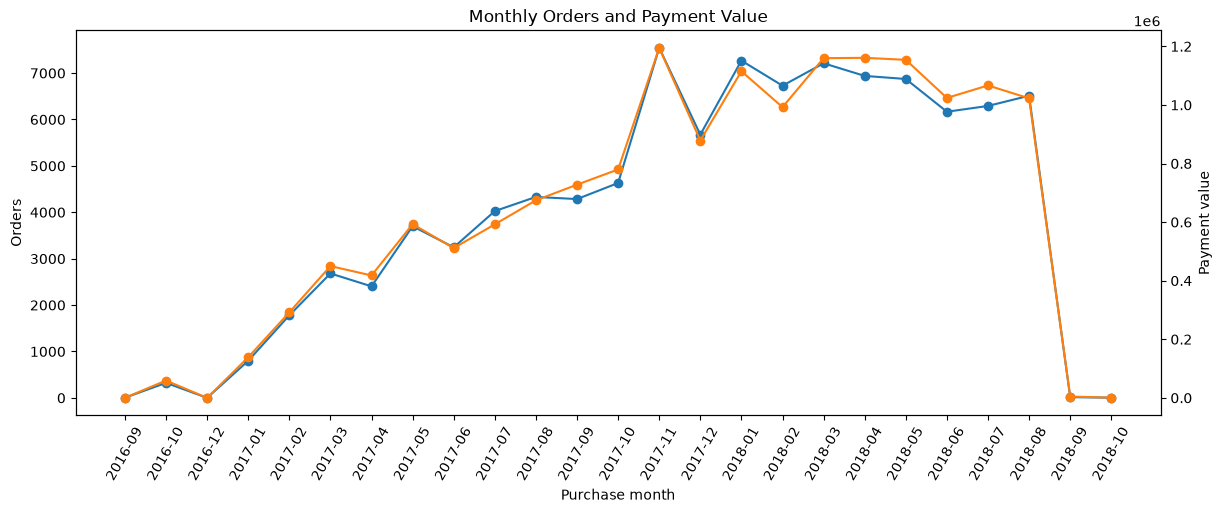

,order_month,orders,revenue
13,2017-11,7544,"1,194,882.80"
14,2017-12,5673,"878,401.48"
15,2018-01,7269,"1,115,004.18"
16,2018-02,6728,"992,463.34"
17,2018-03,7211,"1,159,652.12"
18,2018-04,6939,"1,160,785.48"
19,2018-05,6873,"1,153,982.15"
20,2018-06,6167,"1,023,880.50"
21,2018-07,6292,"1,066,540.75"
22,2018-08,6512,"1,022,425.32"


In [10]:
monthly_orders = (
    orders_enriched
    .dropna(subset=['order_purchase_timestamp'])
    .assign(order_month=lambda d: d['order_purchase_timestamp'].dt.to_period('M').astype(str))
    .groupby('order_month', as_index=False)
    .agg(orders=('order_id', 'nunique'), revenue=('payment_value', 'sum'))
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(monthly_orders['order_month'], monthly_orders['orders'], marker='o', label='Orders')
ax1.set_xlabel('Purchase month')
ax1.set_ylabel('Orders')
ax1.tick_params(axis='x', rotation=60)

ax2 = ax1.twinx()
ax2.plot(monthly_orders['order_month'], monthly_orders['revenue'], marker='o', color='tab:orange', label='Revenue')
ax2.set_ylabel('Payment value')
plt.title('Monthly Orders and Payment Value')
plt.show()

monthly_orders.tail(12)


In [11]:
orders['order_status'].value_counts(normalize=True).rename('share').to_frame().join(
    orders['order_status'].value_counts().rename('orders')
)


,share,orders
order_status,,
delivered,0.97,96478
shipped,0.01,1107
canceled,0.01,625
unavailable,0.01,609
invoiced,0.00,314
processing,0.00,301
created,0.00,5
approved,0.00,2


## 4. Customer Geography

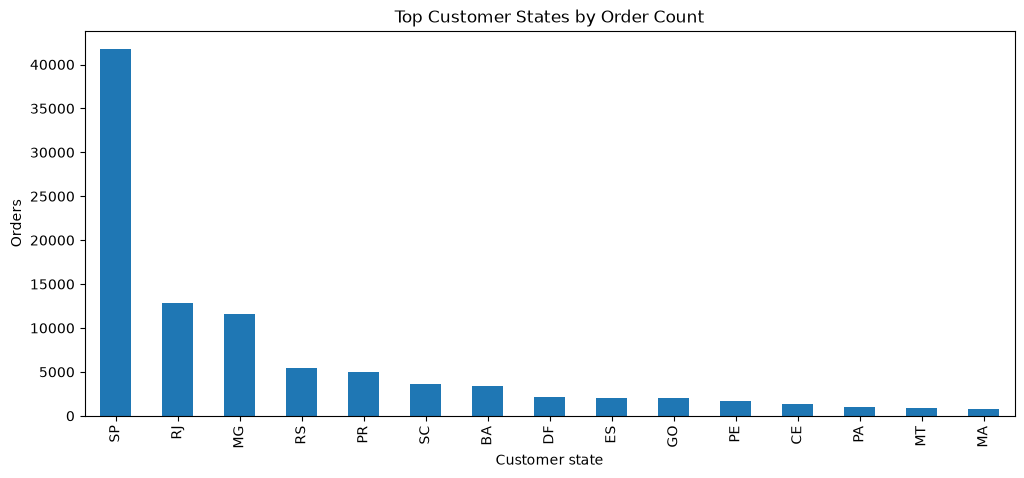

,customer_state,orders,revenue,customers
25,SP,41746,"5,998,226.96",40302
18,RJ,12852,"2,144,379.69",12384
10,MG,11635,"1,872,257.26",11259
22,RS,5466,"890,898.54",5277
17,PR,5045,"811,156.38",4882
23,SC,3637,"623,086.43",3534
4,BA,3380,"616,645.82",3277
6,DF,2140,"355,141.08",2075
7,ES,2033,"325,967.55",1964
8,GO,2020,"350,092.31",1952


In [12]:
state_sales = (
    orders_enriched
    .groupby('customer_state', as_index=False)
    .agg(orders=('order_id', 'nunique'), revenue=('payment_value', 'sum'), customers=('customer_unique_id', 'nunique'))
    .sort_values('orders', ascending=False)
)

state_sales.head(15).plot(kind='bar', x='customer_state', y='orders', figsize=(12, 5), legend=False)
plt.title('Top Customer States by Order Count')
plt.xlabel('Customer state')
plt.ylabel('Orders')
plt.show()

state_sales.head(15)


In [13]:
city_sales = (
    orders_enriched
    .groupby(['customer_state', 'customer_city'], as_index=False)
    .agg(orders=('order_id', 'nunique'), revenue=('payment_value', 'sum'))
    .sort_values('orders', ascending=False)
)
city_sales.head(20)


,customer_state,customer_city,orders,revenue
4176,SP,sao paulo,15540,"2,203,373.09"
2788,RJ,rio de janeiro,6882,"1,161,927.36"
1062,MG,belo horizonte,2773,"421,765.12"
601,DF,brasilia,2131,"354,216.78"
2406,PR,curitiba,1521,"247,392.48"
3729,SP,campinas,1444,"216,248.43"
3208,RS,porto alegre,1379,"224,731.42"
372,BA,salvador,1245,"218,071.50"
3836,SP,guarulhos,1189,"165,121.99"
4160,SP,sao bernardo do campo,938,"120,434.84"


## 5. Product Category and Seller Performance

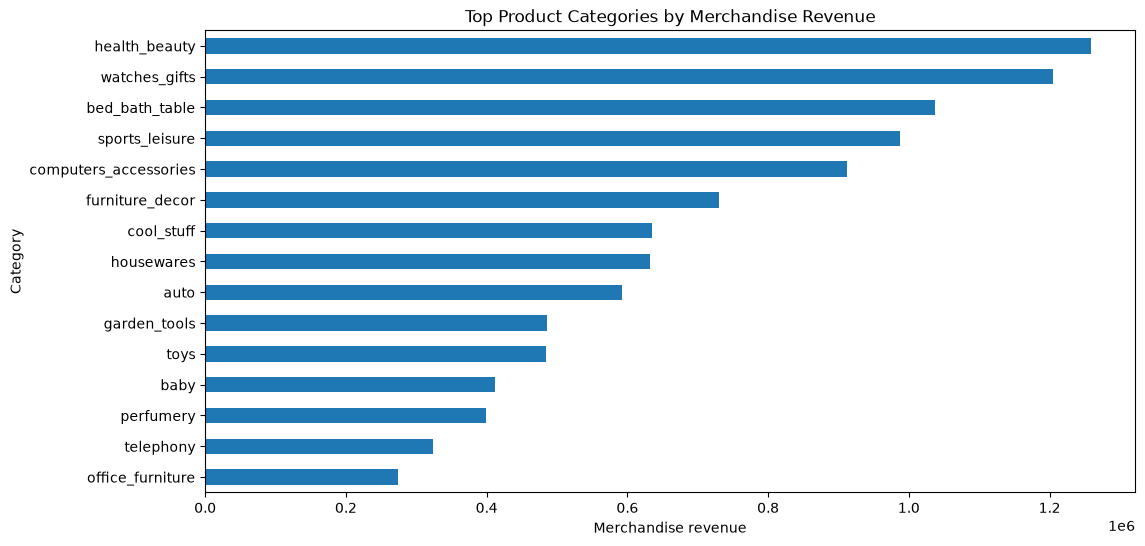

,category,order_items,revenue,freight,sellers
43,health_beauty,9670,"1,258,681.34","182,566.73",492
73,watches_gifts,5991,"1,205,005.68","100,535.93",101
7,bed_bath_table,11115,"1,036,988.68","204,693.04",196
67,sports_leisure,8641,"988,048.97","168,607.51",481
15,computers_accessories,7827,"911,954.32","147,318.08",287
39,furniture_decor,8334,"729,762.49","172,749.30",370
20,cool_stuff,3796,"635,290.85","84,039.10",267
49,housewares,6964,"632,248.66","146,149.11",468
5,auto,4235,"592,720.11","92,664.21",383
42,garden_tools,4347,"485,256.46","98,962.75",237


In [14]:
category_sales = (
    items_products
    .groupby('category', as_index=False)
    .agg(order_items=('order_item_id', 'count'), revenue=('price', 'sum'), freight=('freight_value', 'sum'), sellers=('seller_id', 'nunique'))
    .sort_values('revenue', ascending=False)
)

top_categories = category_sales.head(15).sort_values('revenue')
top_categories.plot(kind='barh', x='category', y='revenue', figsize=(12, 6), legend=False)
plt.title('Top Product Categories by Merchandise Revenue')
plt.xlabel('Merchandise revenue')
plt.ylabel('Category')
plt.show()

category_sales.head(15)


In [15]:
seller_sales = (
    items_products
    .groupby(['seller_id', 'seller_state', 'seller_city'], as_index=False)
    .agg(order_items=('order_item_id', 'count'), revenue=('price', 'sum'), freight=('freight_value', 'sum'), categories=('category', 'nunique'))
    .sort_values('revenue', ascending=False)
)
seller_sales.head(20)


,seller_id,seller_state,seller_city,order_items,revenue,freight,categories
857,4869f7a5dfa277a7dca6462dcf3b52b2,SP,guariba,1156,"229,472.63","20,168.07",10
1013,53243585a1d6dc2643021fd1853d8905,BA,lauro de freitas,410,"222,776.05","13,080.63",2
881,4a3ca9315b744ce9f8e9374361493884,SP,ibitinga,1987,"200,472.92","35,067.04",7
3024,fa1c13f2614d7b5c4749cbc52fecda94,SP,sumare,586,"194,042.03","10,042.70",5
1535,7c67e1448b00f6e969d365cea6b010ab,SP,itaquaquecetuba,1364,"187,923.89","51,612.55",6
1560,7e93a43ef30c4f03f38b393420bc753a,SP,barueri,340,"176,431.87","6,322.18",8
2643,da8622b14eb17ae2831f4ac5b9dab84a,SP,piracicaba,1551,"160,236.57","24,955.75",4
1505,7a67c85e85bb2ce8582c35f2203ad736,SP,sao paulo,1171,"141,745.53","20,902.85",2
192,1025f0e2d44d7041d6cf58b6550e0bfa,SP,sao paulo,1428,"138,968.55","33,892.14",4
1824,955fee9216a65b617aa5c0531780ce60,SP,sao paulo,1499,"135,171.70","25,430.98",23


## 6. Payments and Basket Size

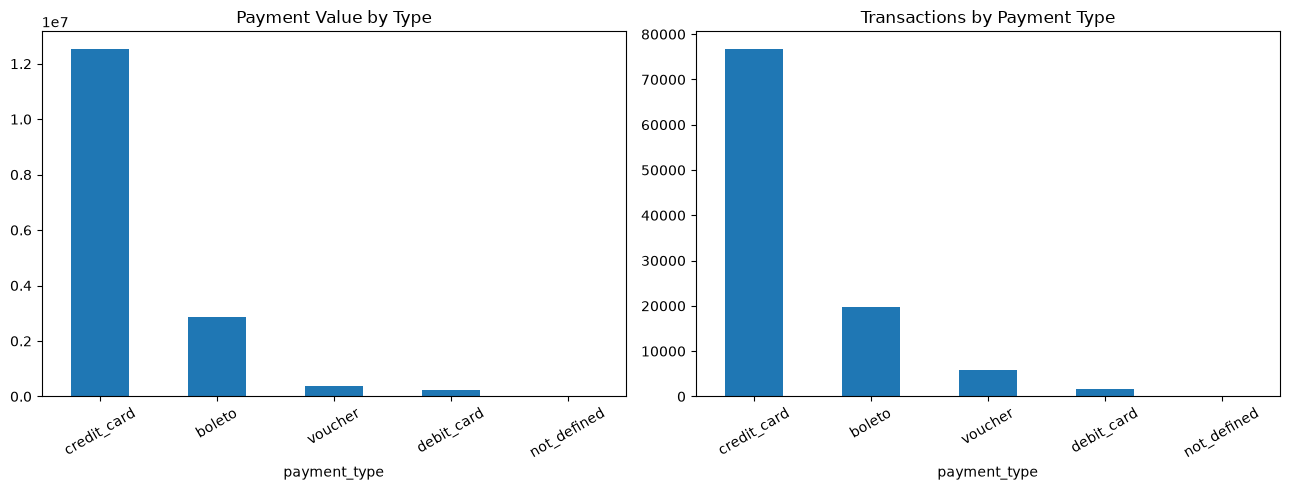

,payment_type,transactions,payment_value,avg_payment,avg_installments
1,credit_card,76795,"12,542,084.19",163.32,3.51
0,boleto,19784,"2,869,361.27",145.03,1.00
4,voucher,5775,"379,436.87",65.70,1.00
2,debit_card,1529,"217,989.79",142.57,1.00
3,not_defined,3,0.00,0.00,1.00


In [16]:
payment_mix = payments.groupby('payment_type', as_index=False).agg(
    transactions=('order_id', 'count'),
    payment_value=('payment_value', 'sum'),
    avg_payment=('payment_value', 'mean'),
    avg_installments=('payment_installments', 'mean'),
).sort_values('payment_value', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
payment_mix.plot(kind='bar', x='payment_type', y='payment_value', ax=axes[0], legend=False)
axes[0].set_title('Payment Value by Type')
axes[0].tick_params(axis='x', rotation=30)
payment_mix.plot(kind='bar', x='payment_type', y='transactions', ax=axes[1], legend=False)
axes[1].set_title('Transactions by Payment Type')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

payment_mix


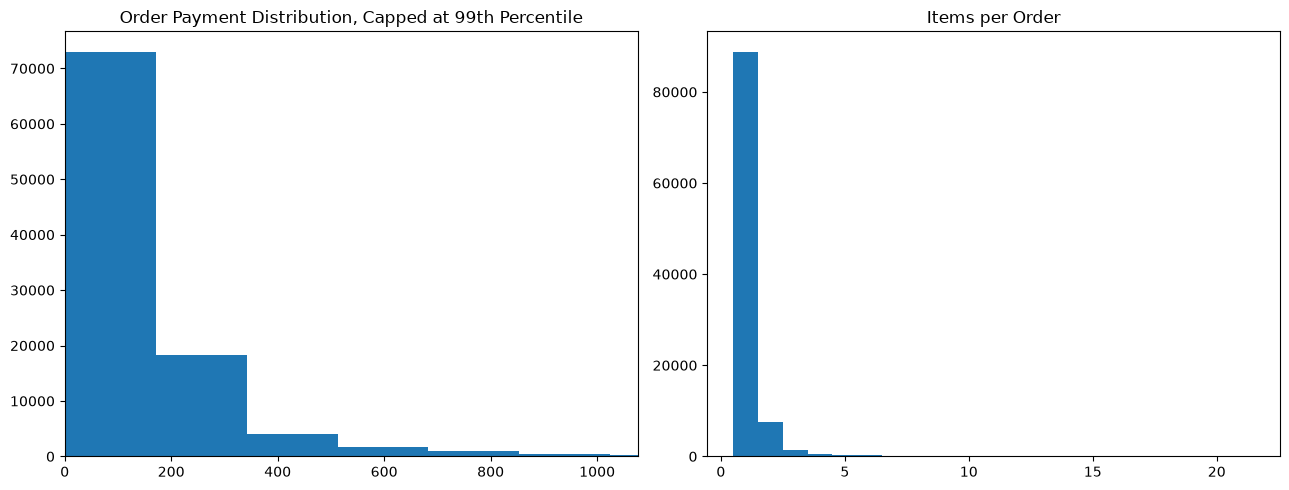

,payment_value
count,"99,440.00"
mean,160.99
std,221.95
min,0.00
50%,105.29
75%,176.97
90%,308.24
95%,452.99
99%,"1,075.79"
max,"13,664.08"


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(order_payments['payment_value'], bins=80)
axes[0].set_xlim(0, order_payments['payment_value'].quantile(0.99))
axes[0].set_title('Order Payment Distribution, Capped at 99th Percentile')
axes[1].hist(order_items['item_count'], bins=np.arange(1, order_items['item_count'].max() + 2) - 0.5)
axes[1].set_title('Items per Order')
plt.tight_layout()
plt.show()

order_payments['payment_value'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame()


## 7. Delivery and Reviews

In [18]:
delivery_summary = orders_enriched['delivery_days'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).to_frame()
late_by_state = (
    orders_enriched[orders_enriched['order_delivered_customer_date'].notna()]
    .groupby('customer_state', as_index=False)
    .agg(orders=('order_id', 'nunique'), late_delivery_rate=('late_delivery', 'mean'), median_delivery_days=('delivery_days', 'median'))
    .sort_values('late_delivery_rate', ascending=False)
)

display(delivery_summary)
display(late_by_state.head(15))


,delivery_days
count,"96,476.00"
mean,12.09
std,9.55
min,0.00
50%,10.00
75%,15.00
90%,23.00
95%,29.00
99%,46.00
max,209.00


,customer_state,orders,late_delivery_rate,median_delivery_days
1,AL,397,0.24,22.00
9,MA,717,0.20,19.00
16,PI,476,0.16,16.00
5,CE,1279,0.15,18.00
24,SE,335,0.15,18.00
4,BA,3256,0.14,16.00
18,RJ,12353,0.13,12.00
26,TO,274,0.13,15.00
13,PA,946,0.12,21.00
7,ES,1995,0.12,13.00


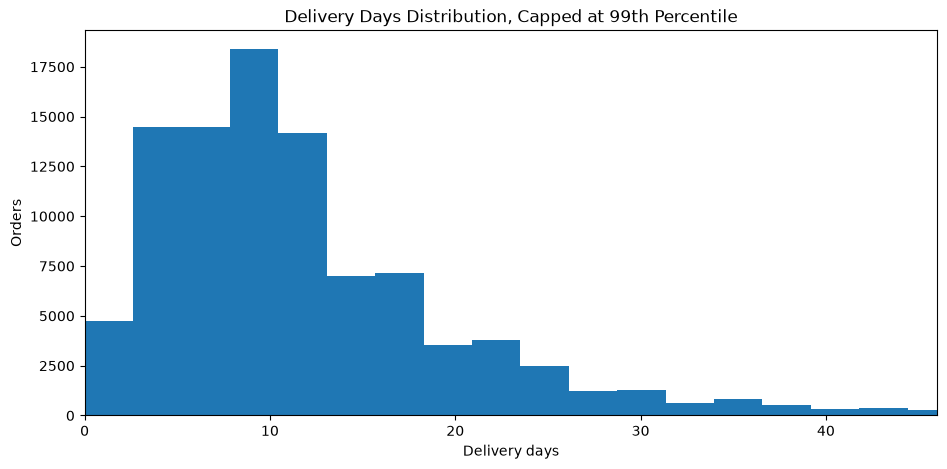

In [19]:
plt.figure(figsize=(11, 5))
plt.hist(orders_enriched['delivery_days'].dropna(), bins=80)
plt.xlim(0, orders_enriched['delivery_days'].quantile(0.99))
plt.title('Delivery Days Distribution, Capped at 99th Percentile')
plt.xlabel('Delivery days')
plt.ylabel('Orders')
plt.show()


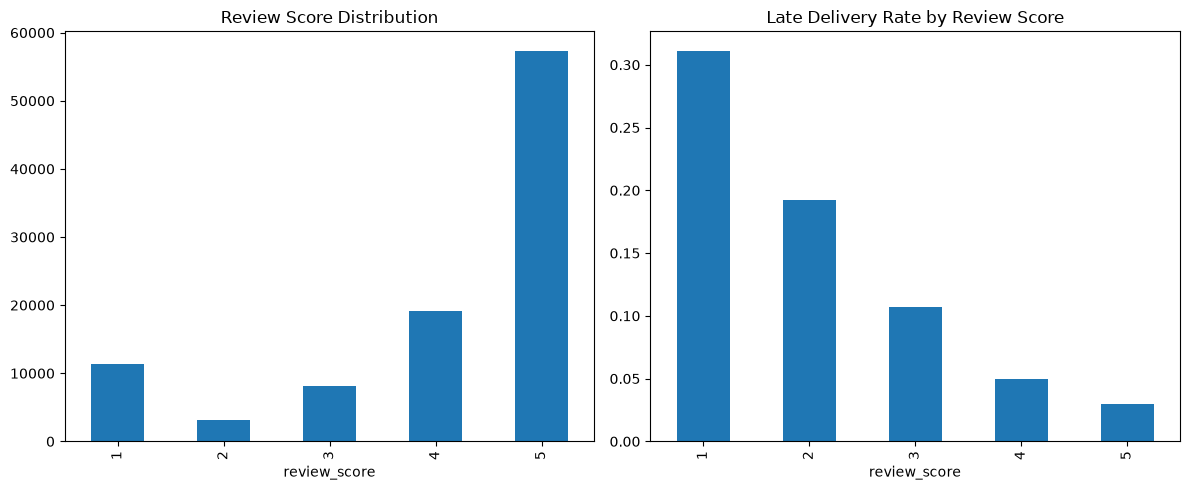

,review_score,reviews,avg_delivery_days,late_delivery_rate,avg_payment_value
0,1,11424,20.85,0.31,195.38
1,2,3151,16.19,0.19,172.65
2,3,8179,13.80,0.11,151.59
3,4,19142,11.85,0.05,154.67
4,5,57328,10.22,0.03,156.21


In [20]:
review_order = reviews.merge(orders_enriched[['order_id', 'delivery_days', 'late_delivery', 'payment_value']], on='order_id', how='left')
review_summary = review_order.groupby('review_score', as_index=False).agg(
    reviews=('review_id', 'count'),
    avg_delivery_days=('delivery_days', 'mean'),
    late_delivery_rate=('late_delivery', 'mean'),
    avg_payment_value=('payment_value', 'mean'),
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[0])
axes[0].set_title('Review Score Distribution')
review_summary.plot(kind='bar', x='review_score', y='late_delivery_rate', ax=axes[1], legend=False)
axes[1].set_title('Late Delivery Rate by Review Score')
plt.tight_layout()
plt.show()

review_summary


## 8. Data Modeling Notes for the Sales Intelligence Platform

Recommended analytical tables after this EDA:

- `dim_customer`: one row per `customer_unique_id`, with geography attributes.
- `dim_seller`: one row per seller, with seller city/state.
- `dim_product`: one row per product, enriched with English category names.
- `fact_order`: one row per order with order status, purchase date, delivery dates, customer key, payment value, merchandise value, freight value, item count, and late delivery flag.
- `fact_order_item`: one row per order item with product, seller, price, freight, and shipping limit date.
- `fact_review`: one row per review/order, useful for customer satisfaction and delivery impact analysis.

Main quality checks to include in ingestion/transformation:

- Validate expected CSV files and required columns.
- Parse date columns with invalid-date handling.
- Keep geolocation duplicates out of dimensional joins unless aggregating by zip prefix first.
- Preserve missing product category fields; do not silently drop those products.
- Treat review title/message missingness as expected sparsity, not a fatal error.
- Check referential integrity across `orders`, `order_items`, `payments`, `reviews`, and dimensions.
